In [3]:
%matplotlib inline
import nifty8 as ift
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 100

n_pix = 1201
x_space = ift.RGSpace(n_pix)
ift.random.push_sseq_from_seed(1)

In [4]:
# Plotting routine
def plot(fields, spectra, title=None):
    # Fields are assumed to have identical domains
    fig = plt.figure(tight_layout=True, figsize=(10, 3))
    if title is not None:
        fig.suptitle(title, fontsize=14)
    
    # Field
    ax1 = fig.add_subplot(1, 2, 1)
    #ax1.axhline(y=0., color='k', linestyle='--', alpha=0.25)
    for field in fields:
        dom = field.domain[0]
        xcoord = np.arange(dom.shape[0]) * dom.distances[0]
        ax1.plot(xcoord, field.val)
    ax1.set_xlim(xcoord[0], xcoord[-1])
    ax1.set_ylim(3., 10.)
    ax1.axhline(y=6.5, color='k', linestyle='--', alpha=0.25)
    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax1.set_title('Field realizations')
    
    # Spectrum
    ax2 = fig.add_subplot(1, 2, 2)
    for spectrum in spectra:
        xcoord = spectrum.domain[0].k_lengths
        ycoord = spectrum.val_rw()
        ycoord[0] = ycoord[1]
        ax2.plot(xcoord, ycoord)
    ax2.set_ylim(1e-6, 10.)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('k')
    ax2.set_ylabel('p(k)')
    ax2.set_title('Power Spectrum')
    
    fig.align_labels()
    plt.show()

# Helper: draw main sample
main_sample = None
def init_model(m_pars, fl_pars, matern=False):
    global main_sample
    cf = ift.CorrelatedFieldMaker(m_pars["prefix"])
    cf.set_amplitude_total_offset(m_pars["offset_mean"], m_pars["offset_std"])
    cf.add_fluctuations_matern(**fl_pars) if matern else cf.add_fluctuations(**fl_pars)
    field = cf.finalize(prior_info=0)
    main_sample = ift.from_random(field.domain)
    print("model domain keys:", field.domain.keys())
    
# Helper: field and spectrum from parameter dictionaries + plotting
def eval_model(m_pars, fl_pars, title=None, samples=None, matern=False):
    cf = ift.CorrelatedFieldMaker(m_pars["prefix"])
    cf.set_amplitude_total_offset(m_pars["offset_mean"], m_pars["offset_std"])
    cf.add_fluctuations_matern(**fl_pars) if matern else cf.add_fluctuations(**fl_pars)
    field = cf.finalize(prior_info=0)
    spectrum = cf.amplitude
    if samples is None:
        samples = [main_sample]
    field_realizations = [field(s) for s in samples]
    spectrum_realizations = [spectrum.force(s) for s in samples]
    plot(field_realizations, spectrum_realizations, title)

def gen_samples(key_to_vary):
    if key_to_vary is None:
        return [main_sample]
    dct = main_sample.to_dict()
    subdom_to_vary = dct.pop(key_to_vary).domain
    samples = []
    for i in range(20):
        d = dct.copy()
        d[key_to_vary] = ift.from_random(subdom_to_vary)
        samples.append(ift.MultiField.from_dict(d))
    return samples
        
def vary_parameter(parameter_key, values, samples_vary_in=None, matern=False):
    s = gen_samples(samples_vary_in)
    for v in values:
        if parameter_key in cf_make_pars.keys():
            m_pars = {**cf_make_pars, parameter_key: v}
            eval_model(m_pars, cf_x_fluct_pars, f"{parameter_key} = {v}", s, matern)
        else:
            fl_pars = {**cf_x_fluct_pars, parameter_key: v}
            eval_model(cf_make_pars, fl_pars, f"{parameter_key} = {v}", s, matern)

model domain keys: ('asperity', 'flexibility', 'fluctuations', 'loglogavgslope', 'spectrum', 'xi', 'zeromode')


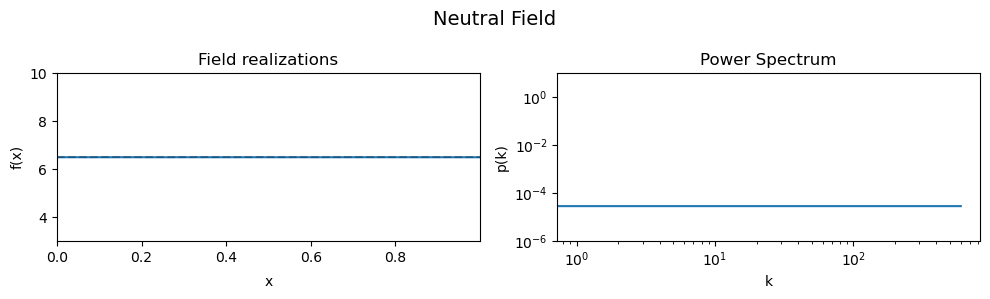

In [5]:
# Neutral model parameters yielding a quasi-constant field
cf_make_pars = {
    'offset_mean': 6.5,
    'offset_std': (1e-3, 1e-16),
    'prefix': ''
}

cf_x_fluct_pars = {
    'target_subdomain': x_space,
    'fluctuations': (1e-3, 1e-16),
    'flexibility': (1e-3, 1e-16),
    'asperity': (1e-3, 1e-16),
    'loglogavgslope': (0., 1e-16)
}

init_model(cf_make_pars, cf_x_fluct_pars)

# Show neutral field
eval_model(cf_make_pars, cf_x_fluct_pars, "Neutral Field")

In [6]:
# vary_parameter('offset_mean', [3.5, 6.5, 9.5])
# vary_parameter('offset_std', [(0.5, 1e-16), (1.5, 1e-16), (2.5, 1e-16)], samples_vary_in='xi')
# vary_parameter('offset_std', [(1., 0.01), (1., 0.1), (1., 1.)], samples_vary_in='zeromode')

In [20]:
# vary_parameter('fluctuations', [(0.5, 1e-16), (1, 1e-16), (1.5, 1e-16)], samples_vary_in='xi')
# vary_parameter('fluctuations', [(0.5, 0.1), (0.5, 0.5), (0.5, 1.)], samples_vary_in='fluctuations')
cf_x_fluct_pars['fluctuations'] = (0.5, 0.5)

In [21]:
# vary_parameter('loglogavgslope', [(-6., 1e-16), (-3., 1e-16), (-1., 1e-16)], samples_vary_in='xi')
# vary_parameter('loglogavgslope', [(-3., 0.03), (-3., 0.3), (-3., 3.0)], samples_vary_in='loglogavgslope')
cf_x_fluct_pars['loglogavgslope'] = (-3., 1e-16)

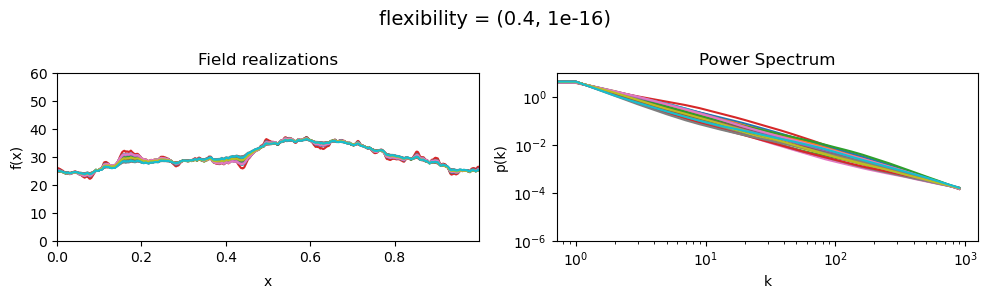

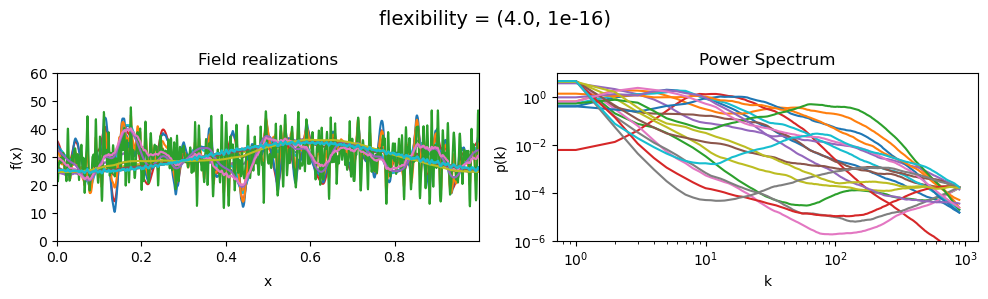

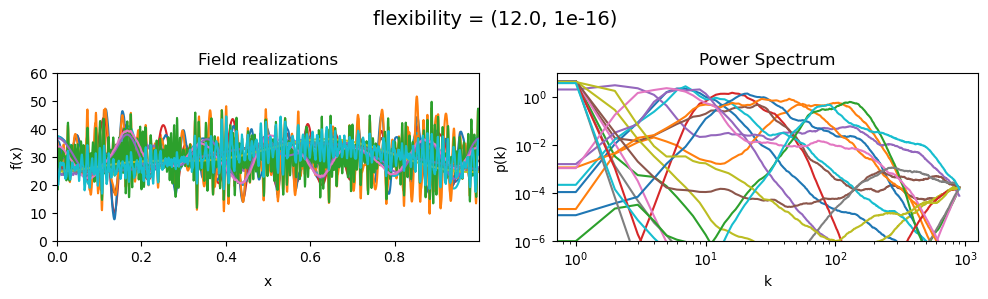

In [183]:
vary_parameter('flexibility', [(0.4, 1e-16), (4.0, 1e-16), (12.0, 1e-16)], samples_vary_in='spectrum')

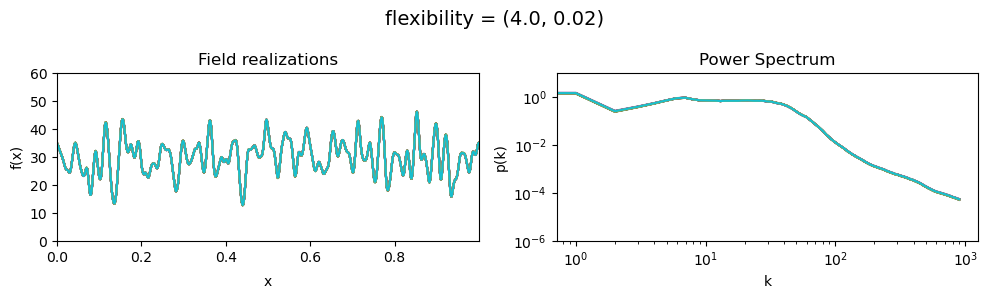

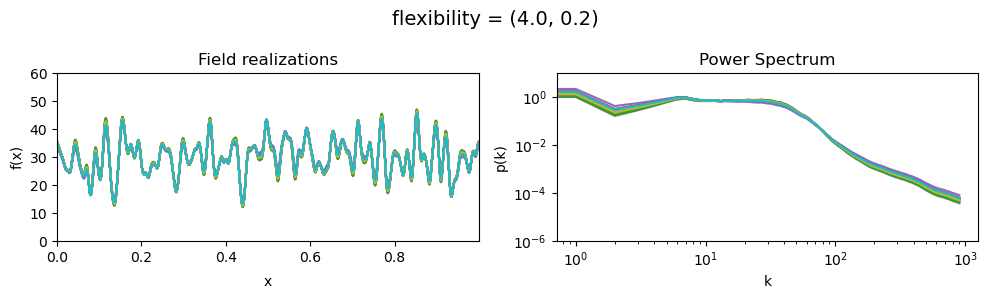

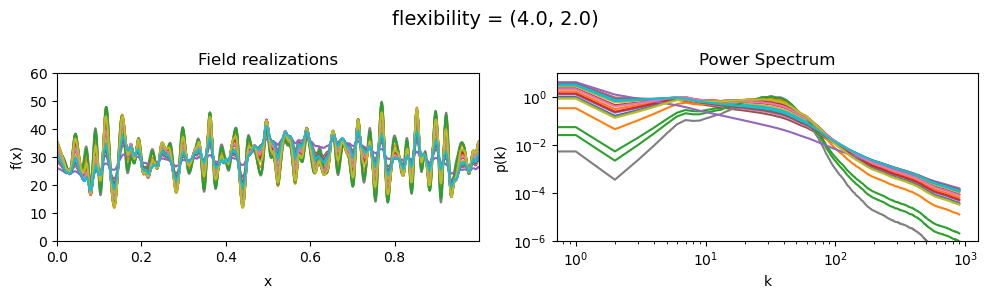

In [184]:
vary_parameter('flexibility', [(4., 0.02), (4., 0.2), (4., 2.)], samples_vary_in='flexibility')
cf_x_fluct_pars['flexibility'] = (4., 1e-16)

In [130]:
# vary_parameter('asperity', [(0.001, 1e-16), (1.0, 1e-16), (5., 1e-16)], samples_vary_in='spectrum')

In [ ]:
# vary_parameter('asperity', [(1., 0.01), (1., 0.1), (1., 1.)], samples_vary_in='asperity')
# cf_x_fluct_pars['asperity'] = (1., 1e-16)

In [ ]:
# Reset model to neutral
cf_x_fluct_pars['fluctuations'] = (1e-3, 1e-16)
cf_x_fluct_pars['flexibility'] = (1e-3, 1e-16)
cf_x_fluct_pars['asperity'] = (1e-3, 1e-16)
cf_x_fluct_pars['loglogavgslope'] = (1e-3, 1e-16)